<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Task_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 12

### Details

Download the zip file floorplans
_
v2-20251223T170650Z-3-001.zip which contains a
large sample of floorplan images. Your task is to train a GAN model based on these
images. Train the model on the floorplan images and create code to generate new
synthetic floorplans.

Hint: check the python notebook SD3_GAN_Illustration.ipynb for context and further details

What I found interesting:
- Yet again a potential Proptech real-life application
- Seeing yet another way to create synthetic floorplans
- Comparing GAN to previous models and justifying why GAN performs better (e.g. convolutional layers preserve spatial structure, which is essential for images like floorplans)

### Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from PIL import Image
from tqdm import tqdm

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
LATENT_DIM  = 100    # size of the noise vector fed into the Generator
IMG_SIZE    = 64     # resize all floorplans to 64x64
CHANNELS    = 3      # RGB
BATCH_SIZE  = 32
LR          = 0.0002
EPOCHS      = 50
BETA1       = 0.5    # Adam momentum — standard for GANs

print(f"Latent dim: {LATENT_DIM} | Image size: {IMG_SIZE}x{IMG_SIZE} | Epochs: {EPOCHS}")

Using device: cuda
Latent dim: 100 | Image size: 64x64 | Epochs: 50


### Floorplan Dataset

In [2]:
class FloorplanDataset(Dataset):
    """
    Loads all jpg/png images from root_dir (recursively),
    resizes to IMG_SIZE x IMG_SIZE, and normalises to [-1, 1]
    to match the Generator's Tanh output range.
    """
    def __init__(self, root_dir, img_size=64):
        self.image_paths = []
        for ext in ['jpg', 'jpeg', 'png', 'JPG', 'JPEG', 'PNG']:
            self.image_paths.extend(
                glob.glob(os.path.join(root_dir, '**', f'*.{ext}'), recursive=True)
            )
        if not self.image_paths:
            raise RuntimeError(f"No images found under {root_dir}")
        print(f"Found {len(self.image_paths)} floorplan images.")

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),                        # [0, 1]
            transforms.Normalize([0.5]*3, [0.5]*3)        # → [-1, 1]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img)


# Point at /content/ where the floorplan jpgs are stored directly
dataset    = FloorplanDataset('/content/', img_size=IMG_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True)
print(f"Dataloader ready — {len(dataloader)} batches per epoch.")

Found 1000 floorplan images.
Dataloader ready — 32 batches per epoch.


### Preview Sample Images

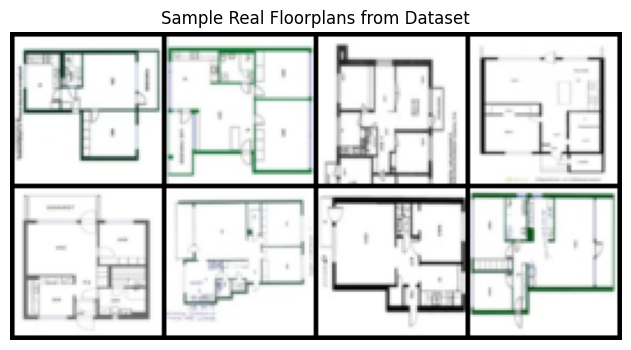

In [3]:
sample_batch = next(iter(dataloader))[:8]
grid = make_grid(sample_batch, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.title('Sample Real Floorplans from Dataset')
plt.axis('off')
plt.show()

Deep Convolutional GAN Architecture

In [4]:
def weights_init(m):
    """Initialise conv and batchnorm weights as recommended in the DCGAN paper."""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# ── Generator ─────────────────────────────────────────────────────────────────
class Generator(nn.Module):
    """
    Transforms a LATENT_DIM noise vector into a 3×64×64 RGB image.
    Each ConvTranspose2d doubles the spatial resolution.
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Input: latent_dim x 1 x 1
            nn.ConvTranspose2d(LATENT_DIM, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # 512 x 4 x 4
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 256 x 8 x 8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 128 x 16 x 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 64 x 32 x 32
            nn.ConvTranspose2d(64, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
            # Output: 3 x 64 x 64  (values in [-1, 1])
        )

    def forward(self, z):
        return self.model(z)


# ── Discriminator ─────────────────────────────────────────────────────────────
class Discriminator(nn.Module):
    """
    Takes a 3×64×64 image and outputs a real/fake probability.
    Each Conv2d halves the spatial resolution.
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Input: 3 x 64 x 64
            nn.Conv2d(CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64 x 32 x 32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128 x 16 x 16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 256 x 8 x 8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # 512 x 4 x 4
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # Output: 1 x 1 x 1  (real/fake score)
        )

    def forward(self, img):
        return self.model(img).view(-1, 1)


# Initialise networks
G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

# Loss and optimisers (Adam with beta1=0.5 per DCGAN paper)
criterion   = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise for tracking generation progress across epochs
fixed_noise = torch.randn(16, LATENT_DIM, 1, 1).to(device)

n_G = sum(p.numel() for p in G.parameters())
n_D = sum(p.numel() for p in D.parameters())
print(f"Generator parameters:     {n_G:,}")
print(f"Discriminator parameters: {n_D:,}")

Generator parameters:     3,576,704
Discriminator parameters: 2,765,568


Training Loop

In [5]:
G_losses, D_losses = [], []

print(f"Starting GAN training for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):
    epoch_loss_G, epoch_loss_D = 0.0, 0.0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1:>3}/{EPOCHS}")

    for real_imgs in pbar:
        real_imgs  = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ── Train Discriminator ───────────────────────────────────────────────
        optimizer_D.zero_grad()

        # Real images → D should output 1
        loss_real = criterion(D(real_imgs), real_labels)

        # Fake images → D should output 0
        z         = torch.randn(batch_size, LATENT_DIM, 1, 1).to(device)
        fake_imgs = G(z).detach()           # detach: don't update G here
        loss_fake = criterion(D(fake_imgs), fake_labels)

        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        optimizer_D.step()

        # ── Train Generator ───────────────────────────────────────────────────
        optimizer_G.zero_grad()

        z         = torch.randn(batch_size, LATENT_DIM, 1, 1).to(device)
        fake_imgs = G(z)
        # Generator wants D to output 1 (real) for its fakes
        loss_G = criterion(D(fake_imgs), real_labels)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()
        pbar.set_postfix(loss_D=f"{loss_D.item():.4f}", loss_G=f"{loss_G.item():.4f}")

    avg_G = epoch_loss_G / len(dataloader)
    avg_D = epoch_loss_D / len(dataloader)
    G_losses.append(avg_G)
    D_losses.append(avg_D)
    print(f"  Epoch {epoch+1:>3} | Loss D: {avg_D:.4f} | Loss G: {avg_G:.4f}")

print("\nTraining complete.")

Starting GAN training for 50 epochs...



Epoch   1/50: 100%|██████████| 32/32 [00:02<00:00, 12.26it/s, loss_D=2.9108, loss_G=17.5096]


  Epoch   1 | Loss D: 0.4948 | Loss G: 10.4736


Epoch   2/50: 100%|██████████| 32/32 [00:01<00:00, 22.56it/s, loss_D=0.1822, loss_G=16.4760]


  Epoch   2 | Loss D: 0.7908 | Loss G: 12.0376


...

  Epoch  48 | Loss D: 0.0707 | Loss G: 5.7011


Epoch  49/50: 100%|██████████| 32/32 [00:01<00:00, 19.78it/s, loss_D=0.0711, loss_G=6.0605]


  Epoch  49 | Loss D: 0.0554 | Loss G: 5.3508


Epoch  50/50: 100%|██████████| 32/32 [00:01<00:00, 20.49it/s, loss_D=0.1106, loss_G=6.1966]

  Epoch  50 | Loss D: 0.0829 | Loss G: 6.2667

Training complete.


Plot Training Losses

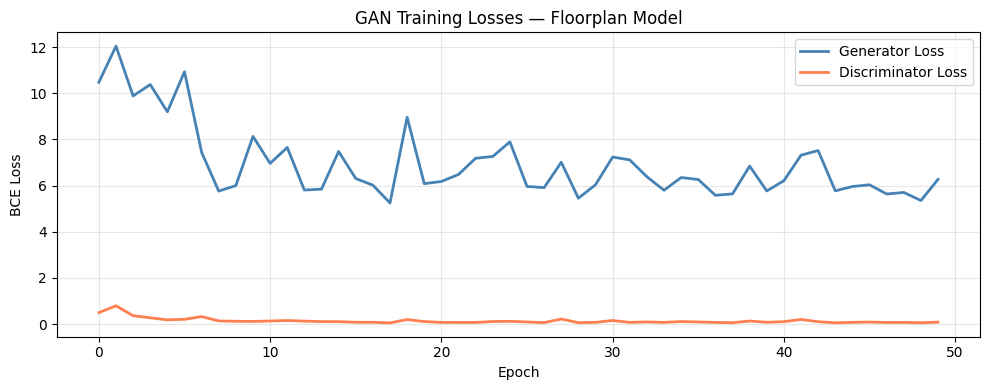

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator Loss',     color='steelblue', linewidth=2)
plt.plot(D_losses, label='Discriminator Loss', color='coral',     linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('GAN Training Losses — Floorplan Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('floorplan_gan_losses.png', dpi=150)
plt.show()

### Save Trained Model

In [7]:
torch.save(G.state_dict(), 'floorplan_generator.pth')
torch.save(D.state_dict(), 'floorplan_discriminator.pth')
print("Generator saved to floorplan_generator.pth")
print("Discriminator saved to floorplan_discriminator.pth")

Generator saved to floorplan_generator.pth
Discriminator saved to floorplan_discriminator.pth


### Generate a Grid of Synthetic Floorplans

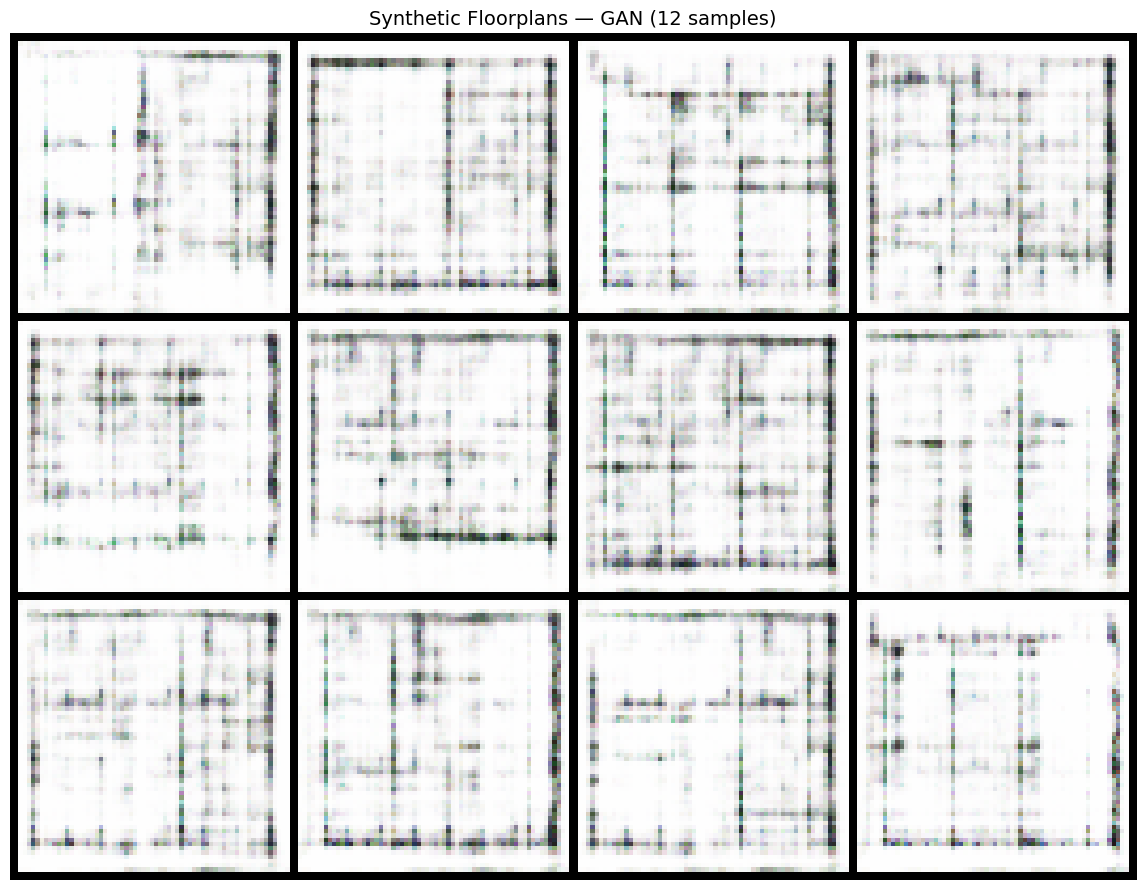

Saved as generated_floorplans_gan.png


In [8]:
def generate_floorplan_grid(generator, n_rows=3, n_cols=4):
    """
    Generate a grid of synthetic floorplan images from random noise.
    """
    generator.eval()
    n_samples = n_rows * n_cols

    with torch.no_grad():
        z         = torch.randn(n_samples, LATENT_DIM, 1, 1).to(device)
        generated = generator(z).cpu()

    grid = make_grid(generated, nrow=n_cols, normalize=True, value_range=(-1, 1))

    plt.figure(figsize=(n_cols * 3, n_rows * 3))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f'Synthetic Floorplans — GAN ({n_samples} samples)', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('generated_floorplans_gan.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved as generated_floorplans_gan.png")
    generator.train()


generate_floorplan_grid(G, n_rows=3, n_cols=4)

Generate a Single Floorplan

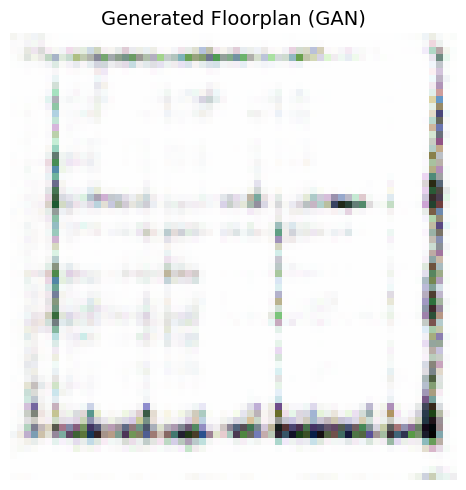

Saved as generated_single_floorplan_gan.png


In [9]:
def generate_single_floorplan(generator):
    """
    Generate and display one synthetic floorplan.
    """
    generator.eval()
    with torch.no_grad():
        z   = torch.randn(1, LATENT_DIM, 1, 1).to(device)
        img = generator(z)[0].cpu().permute(1, 2, 0).numpy()

    img = (img - img.min()) / (img.max() - img.min())   # normalise to [0,1]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title('Generated Floorplan (GAN)', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('generated_single_floorplan_gan.png', dpi=150)
    plt.show()
    print("Saved as generated_single_floorplan_gan.png")
    generator.train()


generate_single_floorplan(G)

### Load and Generate (Standalone)



Generator loaded from floorplan_generator.pth


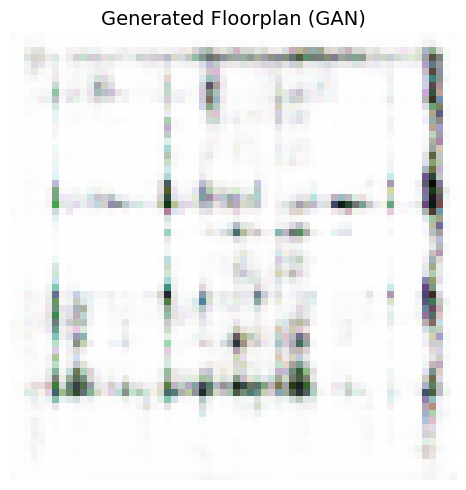

Saved as generated_single_floorplan_gan.png


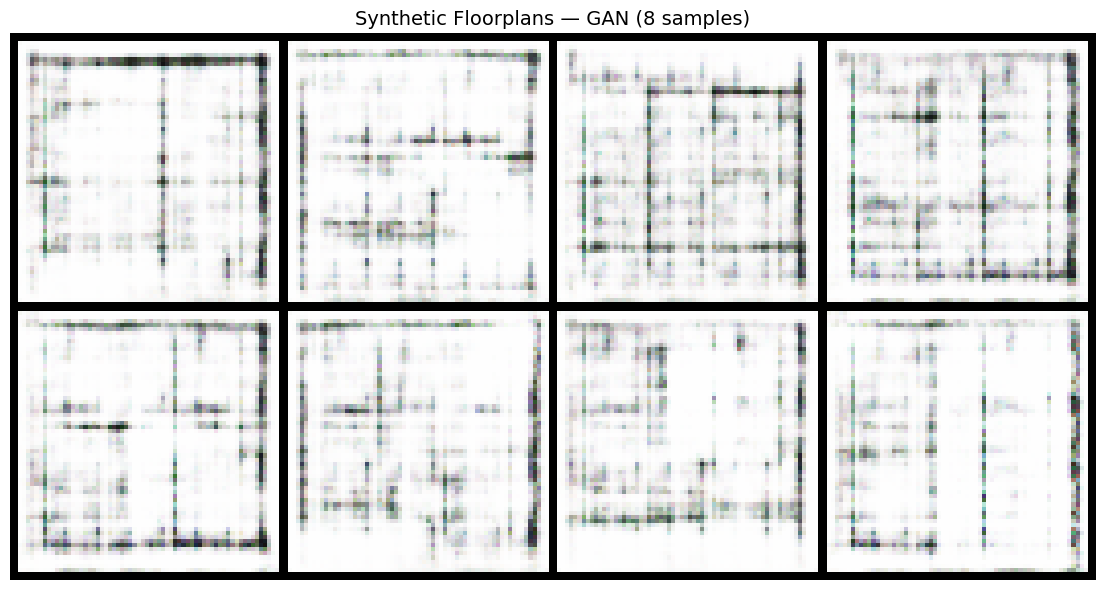

Saved as generated_floorplans_gan.png


In [10]:
def load_generator(filename='floorplan_generator.pth'):
    if not os.path.exists(filename):
        print(f"Error: {filename} not found. Train the model first.")
        return None
    gen = Generator().to(device)
    gen.load_state_dict(torch.load(filename, map_location=device))
    gen.eval()
    print(f"Generator loaded from {filename}")
    return gen


# Example usage
loaded_G = load_generator('floorplan_generator.pth')
if loaded_G:
    generate_single_floorplan(loaded_G)
    generate_floorplan_grid(loaded_G, n_rows=2, n_cols=4)